In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


In [2]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical


In [3]:
train = pd.read_csv('../input/digit-recognizer/train.csv')
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train.shape

(42000, 785)

In [5]:
train.isnull().sum().sum() # Double checking if any null values are present.

0

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
y_train = train[['label']] # Creating target variable
X_train = train.drop('label',axis=1)
X_train.shape                # Rechecking the shape

(42000, 784)

In [8]:
X_train = X_train/255.0     # Scaling the train set

In [9]:
y_train.shape

(42000, 1)

In [10]:
y_train = to_categorical(y_train, num_classes=10) # Converting target var into one-hot encoded vector to train NN

In [11]:
y_train

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [12]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, train_size=0.8) # Creating Validation data 

In [13]:
y_train.shape

(33600, 10)

# Creating the Neural Network****

In [14]:
model = keras.Sequential([
    layers.Dense(units=512, activation='relu', input_shape=[784]),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.3),
    layers.Dense(units=256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.3),
    layers.Dense(units=128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(rate=0.3),
    layers.Dense(units=10, activation='softmax')
])

2022-07-01 17:25:37.764368: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [15]:
model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics='accuracy'
)

In [16]:
history = model.fit(x=X_train, y=y_train,
                    validation_data=(X_val,y_val),
                    batch_size=128,
                    epochs=20
    )

2022-07-01 17:25:38.316476: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/20
263/263 [==============================] - 5s 12ms/step - loss: 0.4083 - accuracy: 0.8743 - val_loss: 0.2142 - val_accuracy: 0.9345
Epoch 2/20
263/263 [==============================] - 3s 11ms/step - loss: 0.1809 - accuracy: 0.9465 - val_loss: 0.1162 - val_accuracy: 0.9621
Epoch 3/20
263/263 [==============================] - 3s 11ms/step - loss: 0.1352 - accuracy: 0.9585 - val_loss: 0.0979 - val_accuracy: 0.9682
Epoch 4/20
263/263 [==============================] - 3s 11ms/step - loss: 0.1125 - accuracy: 0.9656 - val_loss: 0.1060 - val_accuracy: 0.9664
Epoch 5/20
263/263 [==============================] - 3s 11ms/step - loss: 0.0915 - accuracy: 0.9715 - val_loss: 0.0899 - val_accuracy: 0.9723
Epoch 6/20
263/263 [==============================] - 3s 11ms/step - loss: 0.0826 - accuracy: 0.9744 - val_loss: 0.1049 - val_accuracy: 0.9648
Epoch 7/20
263/263 [==============================] - 3s 11ms/step - loss: 0.0756 - accuracy: 0.9761 - val_loss: 0.0953 - val_accuracy: 0.9738

In [17]:
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,accuracy,val_loss,val_accuracy
0,0.408263,0.874256,0.214153,0.934524
1,0.180939,0.946548,0.116152,0.962143
2,0.135165,0.958512,0.097855,0.968214
3,0.112522,0.965566,0.106033,0.966429
4,0.091512,0.971518,0.089853,0.972262


<AxesSubplot:title={'center':'Accuracy'}>

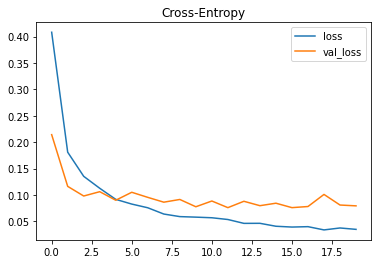

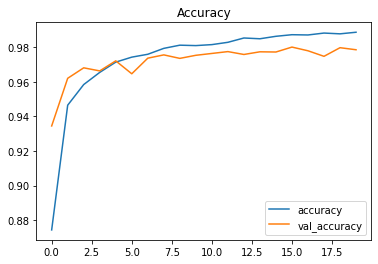

In [18]:
history_df[['loss','val_loss']].plot(title='Cross-Entropy')
history_df[['accuracy','val_accuracy']].plot(title='Accuracy')

In [19]:
test = pd.read_csv('../input/digit-recognizer/test.csv')
test.shape

(28000, 784)

In [20]:
test = test/255.0      # Scaling the test set

In [21]:
results = model.predict(test) # Predict on the test set

results = np.argmax(results,axis = 1) # Select result with Maximum probability

results = pd.Series(results,name="Label")

In [22]:
results

0        2
1        0
2        9
3        9
4        3
        ..
27995    9
27996    7
27997    3
27998    9
27999    2
Name: Label, Length: 28000, dtype: int64

In [23]:
submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),results],axis = 1)

submission.to_csv("DNN_Digi_Recognition1",index=False)